In [1]:
import os 
import h5py
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

import torch 
from torch import nn, optim 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision 
from torchvision import models

from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
path_single = r"/kaggle/input/landslide4sense/TrainData/img/image_2000.h5"
path_single_mask = r'/kaggle/input/landslide4sense/TrainData/mask/mask_2000.h5'

ls ['img']
input data shape: (128, 128, 14)
data ndvi shape  (128, 128) f_data shape:  (1, 128, 128, 3)


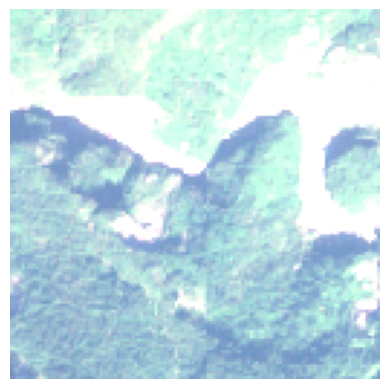

In [4]:
f_data = np.zeros((1, 128,128, 3))
with h5py.File(path_single) as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    data = np.array(hdf.get('img'))
    print("input data shape:", data.shape)
    plt.imshow(data[:, :, 3:0:-1])
    
    data_red = data[:, :, 3]
    data_green = data[:, :, 2]
    data_blue = data[:, :, 1]
    data_nir = data[:, :, 7]
    data_rgb = data[:, :, 3:0:-1]
    data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))
    f_data[0, :, :, 0] =data_ndvi
    f_data[0, :, :, 1] = data[:, :, 12]
    f_data[0, :, :, 2] = data[:, :, 13]

    print("data ndvi shape ", data_ndvi.shape, "f_data shape: ", f_data.shape)
    plt.imshow(data_rgb)
    plt.axis('off')

ls ['mask']
input data shape: (128, 128)


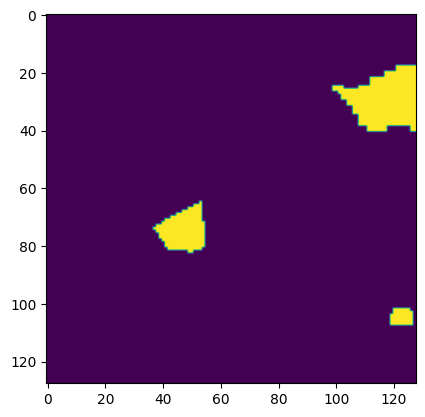

In [5]:
with h5py.File(path_single_mask) as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    data = np.array(hdf.get('mask'))
    print("input data shape:", data.shape)
    plt.imshow(data)

In [6]:
def compute_mean_std(image_dir):
    image_files = sorted(os.listdir(image_dir))
    images = []
    for i in range(len(image_files)):
        image_path = os.path.join(image_dir,image_files[i])
        with h5py.File(image_path,'r') as hdf:
            data = np.array(hdf.get('img'))
            data = np.nan_to_num(data,nan=0.0)
            red = data[:,:,3]
            green = data[:,:,2]
            blue = data[:,:,1]
            nir = data[:,:,7]

            denom = nir + red 
            denom[denom==0] = 1e-6
            ndvi = (nir-red) / denom 

            slope= data[:,:,12]
            elevation = data[:,:,13]
            img = np.stack([red,green,blue,ndvi,slope,elevation],axis=0) # (6x128x128)
            images.append(img)
    images = np.array(images)
    mean = images.mean(axis=(0, 2, 3))
    std = images.mean(axis=(0,2,3))
    return mean, std
            

In [7]:
%%time
# mean, std = compute_mean_std('/kaggle/input/landslide4sense/TrainData/img/')
mean = np.array([0.95963868, 0.95410915, 0.92270051, 0.01454027, 1.25110812, 1.64954336])
std = np.array([0.95963868, 0.95410915, 0.92270051, 0.01454027, 1.25110812, 1.64954336])

CPU times: user 10 µs, sys: 2 µs, total: 12 µs
Wall time: 15.7 µs


In [8]:
print("Channel-wise mean:", mean)
print("Channel-wise std:", std)

Channel-wise mean: [0.95963868 0.95410915 0.92270051 0.01454027 1.25110812 1.64954336]
Channel-wise std: [0.95963868 0.95410915 0.92270051 0.01454027 1.25110812 1.64954336]


In [9]:
class LandslideDataset(Dataset):
    def __init__(self,image_dir, mask_dir, mean, std, image_size=(128,128)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size=image_size
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self,idx):
        image_path = os.path.join(self.image_dir,self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        
        with h5py.File(image_path, 'r') as hdf:
            data = np.array(hdf.get('img'))
            data = np.nan_to_num(data,nan=0.0)
            red = data[:,:,3]
            green = data[:,:,2]
            blue = data[:,:,1]
            nir = data[:,:,7]

            denom = nir + red 
            denom[denom==0] = 1e-6
            ndvi = (nir-red) / denom 

            slope= data[:,:,12]
            elevation = data[:,:,13]
            img = np.stack([red,green,blue,ndvi,slope,elevation],axis=0)
            for c in range(img.shape[0]):
                img[c] = (img[c] - self.mean[c]) /self.std[c]

        img = torch.from_numpy(img).float()

        with h5py.File(mask_path, 'r') as hdf:
            mask_data = np.array(hdf.get('mask')).astype(np.float32)
        mask = torch.from_numpy(mask_data).float().unsqueeze(0)
        return img, mask

In [10]:
train_dataset = LandslideDataset(
        image_dir='/kaggle/input/landslide4sense/TrainData/img',
        mask_dir='/kaggle/input/landslide4sense/TrainData/mask',
    mean=mean, std=std
    )

dataset_size = len(train_dataset)
val_size  = int(0.2 * dataset_size)
train_size = dataset_size  - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [11]:
def show_sample(data_loader,num_rows=5):
    data_iter = iter(data_loader)
    batch_size = num_rows 
    images, masks = next(data_iter)
    images = images[:batch_size].to('cpu')
    masks = masks[:batch_size].to('cpu')

    fig, axes = plt.subplots(num_rows,5,figsize=(5*4,num_rows*4))
    for i in range(batch_size):
        img = images[i].cpu()
        mask = masks[i].cpu()

        img_np = img.permute(1,2,0).numpy()
        if mask.ndim==3 and mask.shape[0] == 1:
            mask_np = mask.squeeze(0).numpy()
        else:
            mask_np = mask.numpy()
        # also denormalize these 
        rgb = img_np[:,:,:3] * std[:3] + mean[:3]
        ndvi = img_np[:,:,3] * std[3] + mean[3]
        slope = img_np[:,:,4] * std[4] + mean[4]
        elevation = img_np[:,:,5] * std[5] + mean[5]
        axes[i,0].imshow(rgb)
        axes[i,0].axis('off')
        axes[i,0].set_title('RGB')

        axes[i,1].imshow(ndvi)
        axes[i,1].axis('off')
        axes[i,1].set_title('NDVI')

        axes[i,2].imshow(slope)
        axes[i,2].axis('off')
        axes[i,2].set_title('Slope')

        axes[i,3].imshow(elevation)
        axes[i,3].axis('off')
        axes[i,3].set_title('Elevation')

        axes[i,4].imshow(mask_np)
        axes[i,4].axis('off')
        axes[i,4].set_title('Mask')
    plt.tight_layout()
    plt.show()

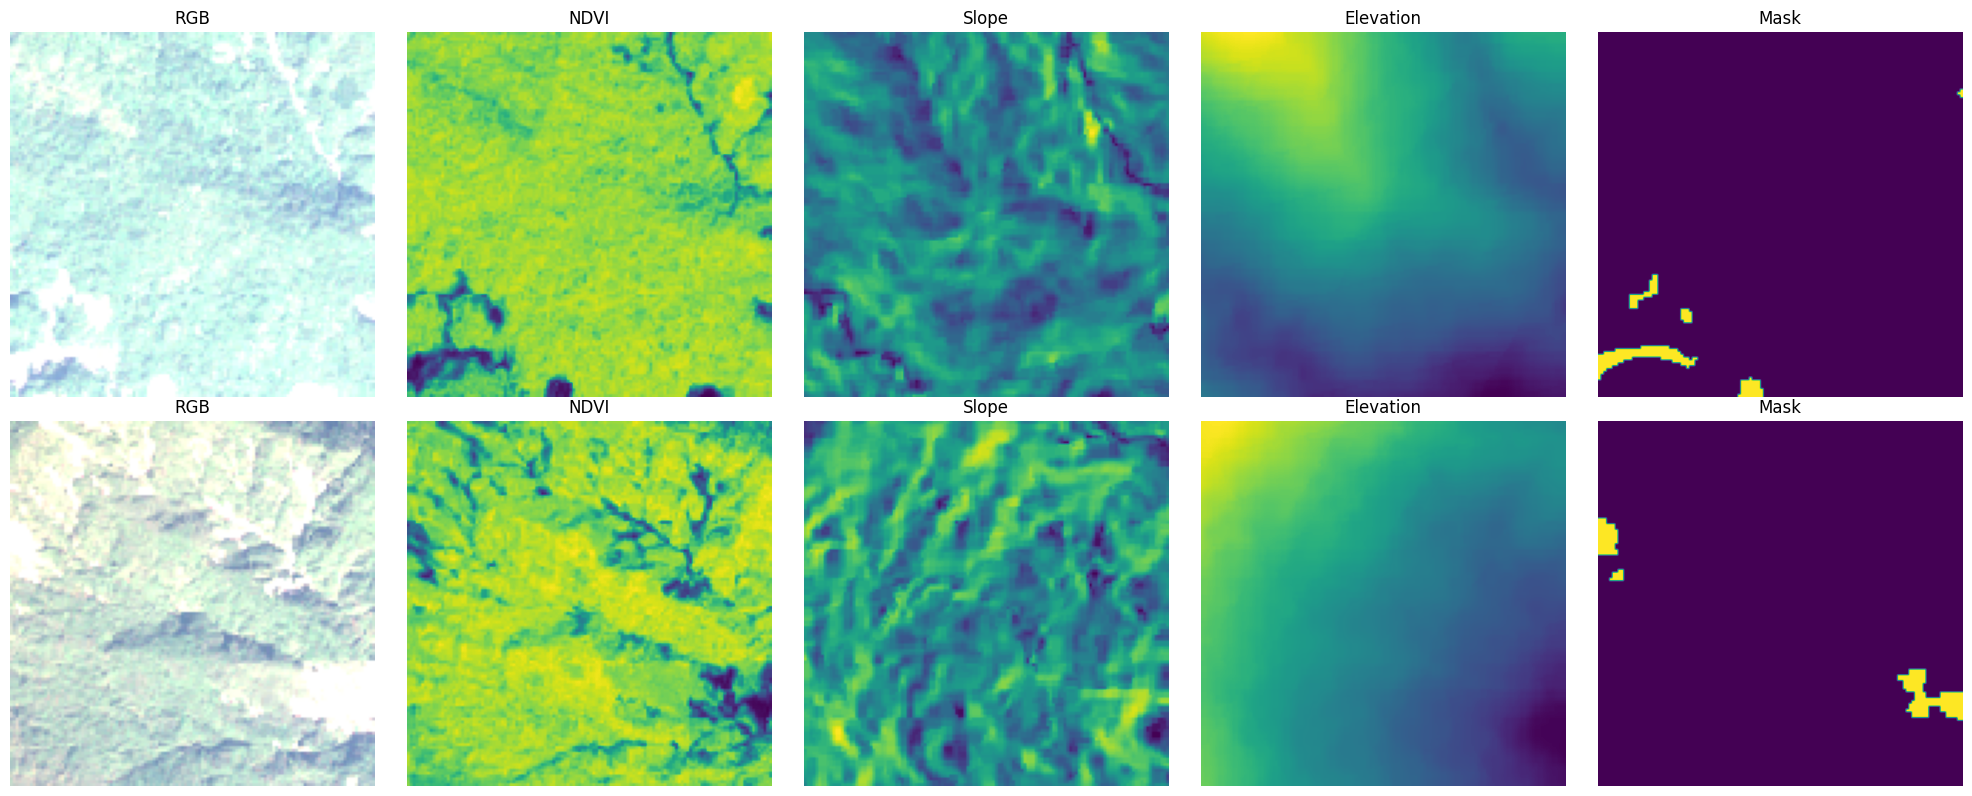

In [12]:
show_sample(train_loader,2)

In [13]:
class ResidualConv(nn.Module):
    def __init__(self, in_channels, out_channels, droprate, is_res=False):
        super().__init__()
        self.is_res = is_res 
        
        self.conv1_layer = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, out_channels),   # FIXED HERE
            nn.SiLU(),
            nn.Dropout2d(droprate)    
        )
        self.conv2_layer = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, out_channels),   # FIXED HERE
            nn.SiLU()
        )

        if is_res:
            if in_channels == out_channels:
                self.resid_layer = nn.Identity()
            else:
                self.resid_layer = nn.Conv2d(in_channels, out_channels, 1, 1, 0)

    def forward(self, x):
        x1 = self.conv1_layer(x)
        x2 = self.conv2_layer(x1)
        if self.is_res:
            out = x2 + self.resid_layer(x)
            return out / 1.414
        else:
            return x2


class Downsample(nn.Module):
    def __init__(self,in_channels,out_channels,dropout_rate):
        super().__init__()
        self.conv = ResidualConv(in_channels,out_channels,dropout_rate)
        self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        x = self.conv(x)
        x_pool = self.pool(x)
        return x_pool,x

class Upsample(nn.Module):
    def __init__(self,in_channels, out_channels,dropout_rate):
        super().__init__()
        layers = [ResidualConv(in_channels,out_channels,dropout_rate)]
        self.layer = nn.Sequential(*layers)
    def forward(self,x,skip):
        x = F.interpolate(x,scale_factor=2,mode='bilinear',align_corners=True)
        x = torch.cat((x,skip),dim=1)
        return self.layer(x)


In [14]:
# --------------------------- BLOCK A: Attention Gate ---------------------------
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi



In [15]:
class TinyAttentionGate(nn.Module):
    def __init__(self, F_g, F_l):
        super().__init__()
        F_int = F_g // 2

        self.W_g = nn.Conv2d(F_g, F_int, 1, bias=False)
        self.W_x = nn.Conv2d(F_l, F_int, 1, bias=False)
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class TinyAttentionUNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()

        # Encoder
        self.down1 = Downsample(in_channels, 16, 0.05)
        self.down2 = Downsample(16, 32, 0.05)
        self.down3 = Downsample(32, 64, 0.05)

        # Bottleneck
        self.bottle = ResidualConv(64, 128, 0.05)

        # Tiny Attention Gates
        self.ag3 = TinyAttentionGate(128, 64)
        self.ag2 = TinyAttentionGate(64, 32)
        self.ag1 = TinyAttentionGate(32, 16)

        # Decoder
        self.up1 = Upsample(128 + 64, 64, 0.05)
        self.up2 = Upsample(64 + 32, 32, 0.05)
        self.up3 = Upsample(32 + 16, 16, 0.05)

        # Output
        self.out_layer = nn.Conv2d(16, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        # Encoder
        x1p, x1 = self.down1(x)
        x2p, x2 = self.down2(x1p)
        x3p, x3 = self.down3(x2p)

        # Bottleneck
        b = self.bottle(x3p)

        # Decoder + Attention
        g3 = F.interpolate(b, size=x3.shape[2:], mode='bilinear', align_corners=True)
        x3a = self.ag3(g3, x3)
        d1 = self.up1(b, x3a)

        g2 = F.interpolate(d1, size=x2.shape[2:], mode='bilinear', align_corners=True)
        x2a = self.ag2(g2, x2)
        d2 = self.up2(d1, x2a)

        g1 = F.interpolate(d2, size=x1.shape[2:], mode='bilinear', align_corners=True)
        x1a = self.ag1(g1, x1)
        d3 = self.up3(d2, x1a)

        return torch.sigmoid(self.out_layer(d3))




In [16]:
class UNET(nn.Module):
    def __init__(self,in_channels=6,out_channels=1):
        super(UNET,self).__init__()
        self.in_channels = in_channels

        # encoder 
        self.down1 = Downsample(in_channels,64,0.1) # 128x128x6 -> 64x64x64
        self.down2 = Downsample(64,128,0.1) # 64x64x64 -> 32x32x128
        self.down3 = Downsample(128,256,0.2) # 32x32x128 -> 16x16x256
        self.down4 = Downsample(256,512,0.2) # 16x16x256 -> 8x8x512
        
        # bottleneck 
        self.bottle = ResidualConv(512,512,0.3) # 8x8x512 -> 8x8x512

        # decoder 
        self.up1 = Upsample(512*2,256,0.2)
        self.up2 = Upsample(256*2,128,0.2)
        self.up3 = Upsample(128*2,64,0.1)
        self.up4 = Upsample(64*2,32,0.1)

        # output 
        self.out_layer = nn.Conv2d(32,out_channels,kernel_size=3,padding=1)
    def forward(self,x):
        x1_pool, x1 = self.down1(x)
        x2_pool, x2 = self.down2(x1_pool)
        x3_pool, x3 = self.down3(x2_pool)
        x4_pool, x4 = self.down4(x3_pool)

        bottle = self.bottle(x4_pool)

        d1 = self.up1(bottle,x4)
        d2 = self.up2(d1,x3)
        d3 = self.up3(d2,x2)
        d4 = self.up4(d3,x1)

        out = torch.sigmoid(self.out_layer(d4))
        return out

In [17]:
LEARNING_RATE = 0.001
LR_FACTOR = 0.5
LR_PATIENCE = 2
EARLY_STOP_PATIENCE = 4
NUM_EPOCHS = 20
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TinyAttentionUNet().to(device)




def dice_loss(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    
    intersection = (pred * target).sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)
    
    return 1 - dice.mean()

def bce_dice_loss(pred, target):
    bce = nn.BCELoss()(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

criterion = bce_dice_loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

In [18]:
from sklearn.metrics import accuracy_score

def compute_metrics(y_pred, y_true):
    y_pred = (y_pred > 0.3).cpu().numpy().astype(np.uint8).flatten()
    y_true = y_true.cpu().numpy().astype(np.uint8).flatten()

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'dice': f1_score(y_true, y_pred, zero_division=0),
        'iou': jaccard_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0)
    }

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, early_stop_patience=4):
    best_val_loss = float('inf')
    early_stop_counter = 0
    history = {'loss':[],'accuracy':[],'dice':[],'iou':[],'precision':[],'recall':[]}

    train_losses = []
    val_losses = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        metrics = {'dice':0,'iou':0,'precision':0,'recall':0}

        for batch_idx, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            batch_metrics = compute_metrics(outputs, masks)
            for k in metrics:
                metrics[k] += batch_metrics[k]

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        history['loss'].append(avg_train_loss)
        for k in metrics:
            history[k].append(metrics[k] / len(train_loader))

        # Validation phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate scheduler
        scheduler.step(avg_val_loss)

        # Print and check for early stopping
        print(f'Epoch [{epoch}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Learning Rate: {scheduler.get_last_lr()[0]}')

        if avg_val_loss < best_val_loss:
            torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
            best_val_loss = avg_val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= early_stop_patience:
            print(f'Early stopping after {early_stop_patience} epochs without improvement.')
            break

    return train_losses, val_losses, history

In [20]:
%%time
train_losses, val_losses, history = train_model( model, train_loader, val_loader, criterion, optimizer, scheduler,num_epochs=50, early_stop_patience=4)


Epoch [1/50], Train Loss: 0.8471, Validation Loss: 0.7803, Learning Rate: 0.001
Epoch [2/50], Train Loss: 0.7554, Validation Loss: 0.7633, Learning Rate: 0.001
Epoch [3/50], Train Loss: 0.7452, Validation Loss: 0.7472, Learning Rate: 0.001
Epoch [4/50], Train Loss: 0.7294, Validation Loss: 0.7424, Learning Rate: 0.001
Epoch [5/50], Train Loss: 0.7211, Validation Loss: 0.7311, Learning Rate: 0.001
Epoch [6/50], Train Loss: 0.7186, Validation Loss: 0.7423, Learning Rate: 0.001
Epoch [7/50], Train Loss: 0.7174, Validation Loss: 0.7249, Learning Rate: 0.001
Epoch [8/50], Train Loss: 0.7094, Validation Loss: 0.7278, Learning Rate: 0.001
Epoch [9/50], Train Loss: 0.7105, Validation Loss: 0.7253, Learning Rate: 0.001
Epoch [10/50], Train Loss: 0.7055, Validation Loss: 0.7172, Learning Rate: 0.001
Epoch [11/50], Train Loss: 0.7017, Validation Loss: 0.7205, Learning Rate: 0.001
Epoch [12/50], Train Loss: 0.6993, Validation Loss: 0.7274, Learning Rate: 0.001
Epoch [13/50], Train Loss: 0.7010, Va

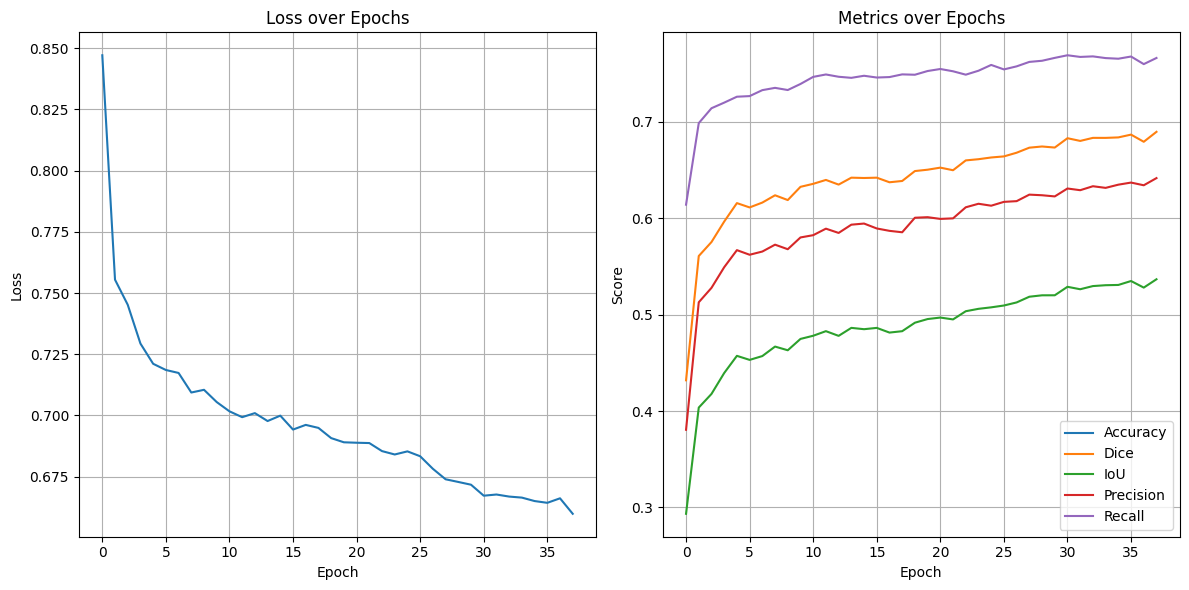

In [21]:
# plotting only train metric and loss 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Accuracy')
plt.plot(history['dice'], label='Dice')
plt.plot(history['iou'], label='IoU')
plt.plot(history['precision'], label='Precision')
plt.plot(history['recall'], label='Recall')
plt.title('Metrics over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

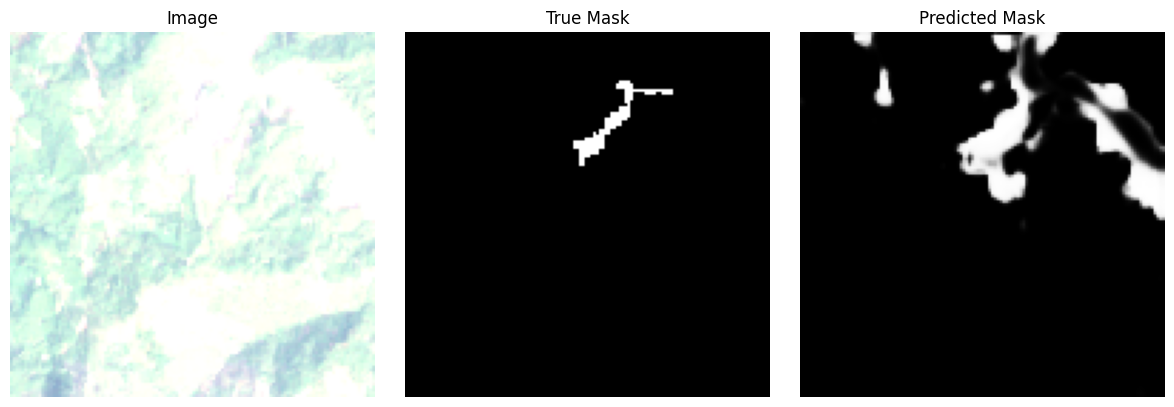

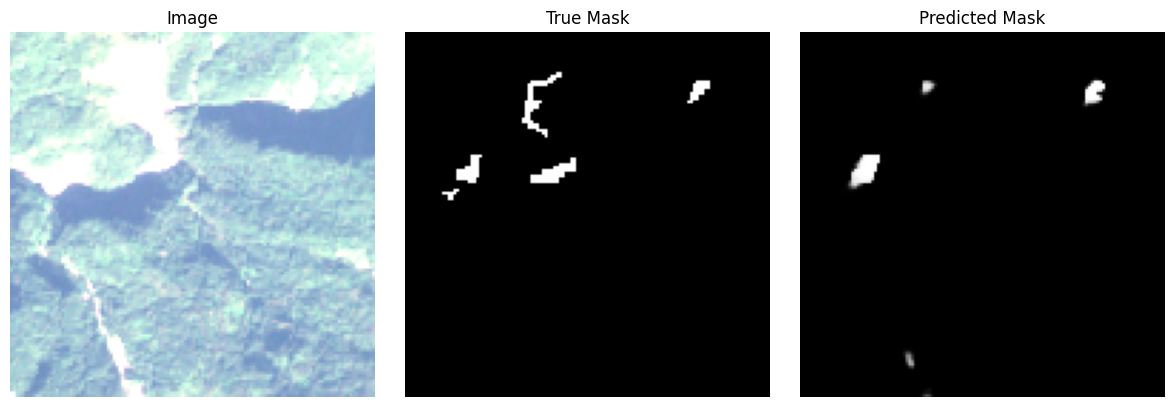

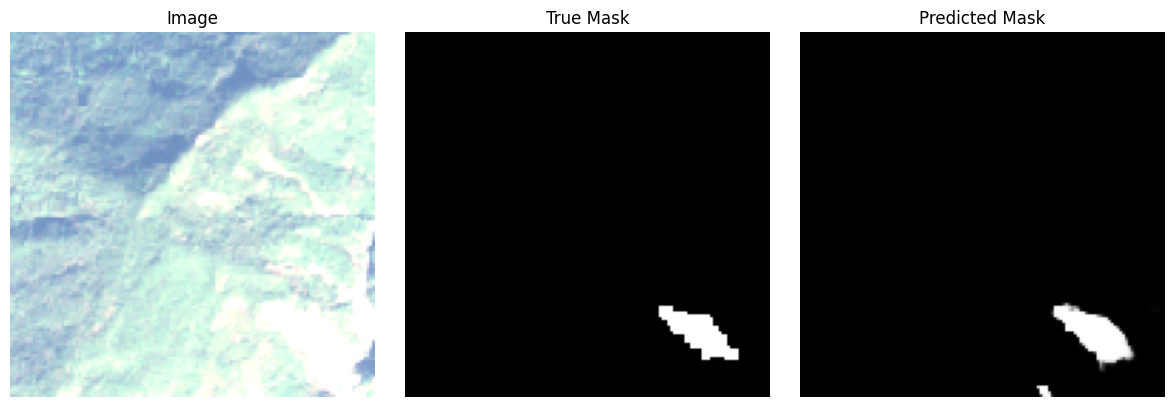

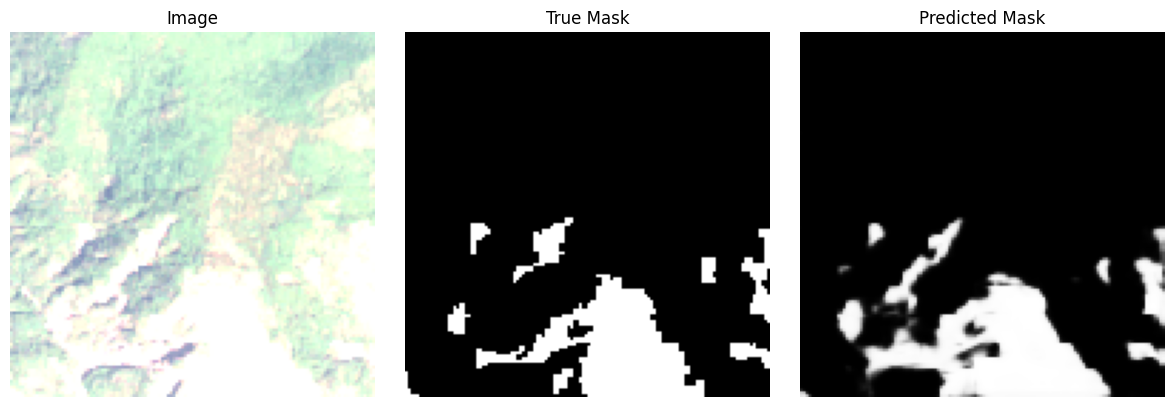

In [22]:
# Function to plot examples with predicted and true masks
def plot_examples(model, dataset, num_examples=5):
    model.eval()
    
    for i in range(num_examples):
        image, mask = dataset[i]
        
        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device)).cpu()
        
        pred_mask = output.squeeze(0)#torch.argmax(output, dim=1)
        
        # Plot the images and masks
        plt.figure(figsize=(12, 4))
        image = (image[:3].permute(1,2,0).numpy()) * std[:3] + mean[:3]
        
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title('Image')
        
        plt.subplot(1, 3, 2)
        plt.imshow(mask.permute(1,2,0), cmap='gray')
        plt.axis("off")
        plt.title('True Mask')
        
        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask.permute(1,2,0), cmap='gray')
        plt.axis("off")
        plt.title('Predicted Mask')
        
        plt.tight_layout()
        plt.show()

# Plot examples from the test dataloader
plot_examples(model, train_dataset, num_examples=4)